# TensorFlow: Custom training

In [ ]:
import os
import matplotlib.pyplot as plt
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

import tensorflow as tf

print("TF Version: ", tf.__version__)
print("TF Eager mode: ", tf.executing_eagerly())
print("TF GPU is", "available" if tf.config.list_physical_devices("GPU") else "not available")

In [ ]:
def plot_data(inputs, outputs, predicted_outputs):
  real = plt.scatter(inputs, outputs, c='b', marker='.')
  predicted = plt.scatter(inputs, predicted_outputs, c='r', marker='+')
  plt.legend((real,predicted), ('Real Data', 'Predicted Data'))
  plt.show()

## Generate Training Data

Generate training data using simple linear regression

In [ ]:
# Values of parameters
TRUE_w = 3.0
TRUE_b = 2.0
# Number of examples
NUM_EXAMPLES = 1_000

In [ ]:
# Generate training data
xs = tf.random.normal(shape=[NUM_EXAMPLES])
ys = (TRUE_w * xs) + TRUE_b

## Define Model

In [ ]:
class Model(object):
    def __init__(self):
        w_init = tf.random_normal_initializer()
        self.w = tf.Variable(initial_value=w_init(shape=[1], dtype=tf.float32), trainable=True)
        b_init = tf.zeros_initializer()
        self.b = tf.Variable(initial_value=b_init(shape=[1], dtype=tf.float32), trainable=True)

    def __call__(self, x):
        return tf.multiply(self.w, x) + self.b

In [ ]:
model = Model()

In [ ]:
plot_data(xs, ys, model(xs))

## Train Model

In [ ]:
# Define loss function
def loss(y_pred, y_true):
  return tf.reduce_mean(tf.square(y_pred - y_true))

In [ ]:
# Define training loop
def train(model, inputs, outputs, lr):
    with tf.GradientTape() as tape:
        # Predict y values
        y_pred = model(inputs)
        # Calculate loss value
        curr_loss = loss(y_pred, outputs)
    # Calculate gradients for w and b parameters
    dw, db = tape.gradient(curr_loss, [model.w, model.b])
    # Update parameters using gradients
    model.w.assign_sub(lr * dw)
    model.b.assign_sub(lr * db)
    return curr_loss

In [ ]:
model = Model()

losses = []
ws, bs = [], []
epochs = range(15)
for epoch in epochs:
    ws.append(model.w.numpy())
    bs.append(model.b.numpy())
    curr_loss = train(model, xs, ys, lr=1e-1)
    losses.append(curr_loss)
    print(f"Epoch {epoch:02d}: w={ws[-1][0]:.2f}, b={bs[-1][0]:.2f}, loss={losses[-1]:.5f}")

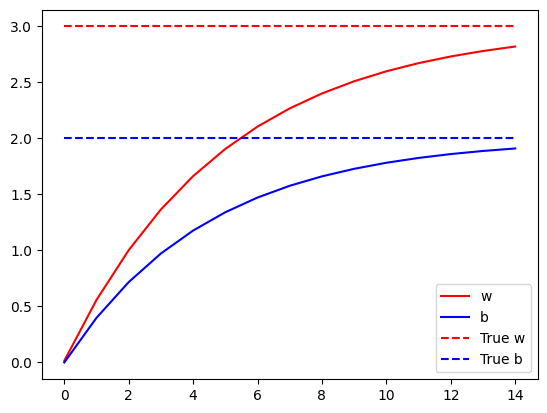

In [59]:
plt.plot(epochs, ws, "r",
         epochs, bs, "b")
plt.plot([TRUE_w] * len(epochs), 'r--',
         [TRUE_b] * len(epochs), 'b--')
plt.legend(["w", "b", "True w", "True b"])
plt.show()

## Evaluation

In [ ]:
xs_test = tf.random.normal(shape=[NUM_EXAMPLES])
ys_test = (TRUE_w * xs_test)  + TRUE_b

In [ ]:
plot_data(xs_test, ys_test, model(xs_test))

In [ ]:
weights = [{
    "name" : "w",
    "values" : ws
}, {
    "name" : "b",
    "values" : bs
}]

In [ ]:
for idx, weights in enumerate(weights):
    plt.subplot(120 + idx + 1)
    plt.plot(weights["values"], losses, "r")
    plt.plot(weights["values"], losses, "bo")
    plt.xlabel(weights["name"])
    plt.ylabel("Loss")